In [1]:
#2021.08.16. MON
#Team_밥믈리에
 
## EDA of Cultivar Review Distribution
#00. 패키지 호출
import warnings 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')

#00-2. 시각화 옵션 설정하기.  
%matplotlib inline
#mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = 'D2Coding'

#00-3. 사전 변수 정의하기
CULTIVAR_LIST = ['고시히카리', '골드퀸', '밀키퀸', '삼광', '새청무', '새누리', '신동진', '영호진미', '오대', '일품', '진상', '참드림', '추청', '하이아미', '히토메보레'] 


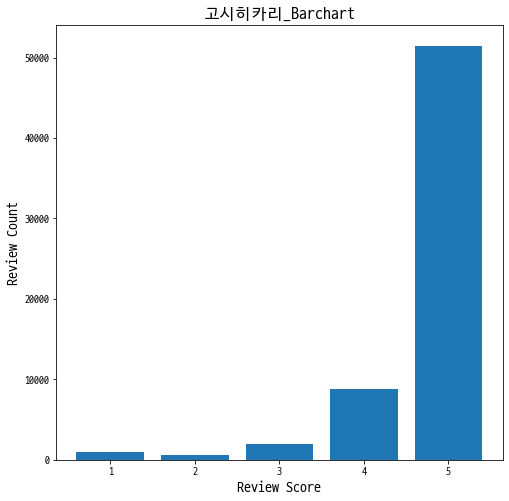

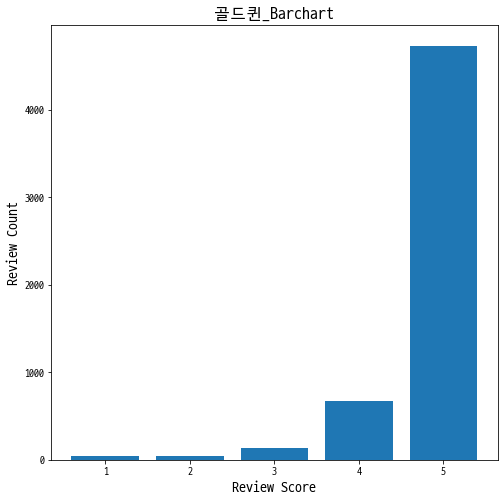

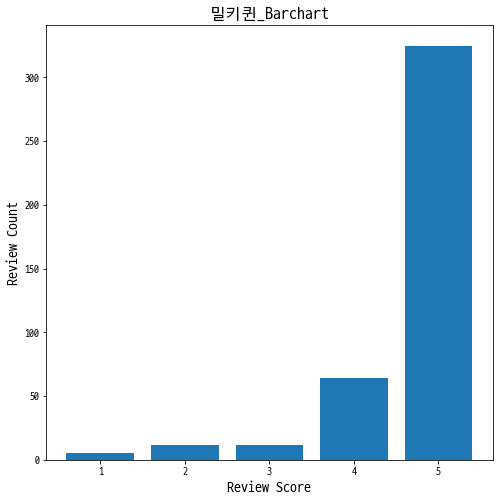

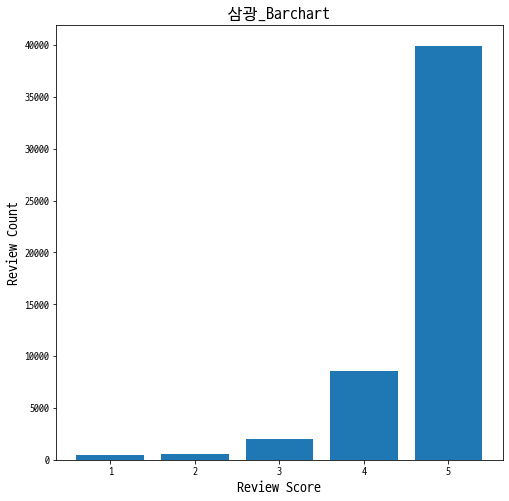

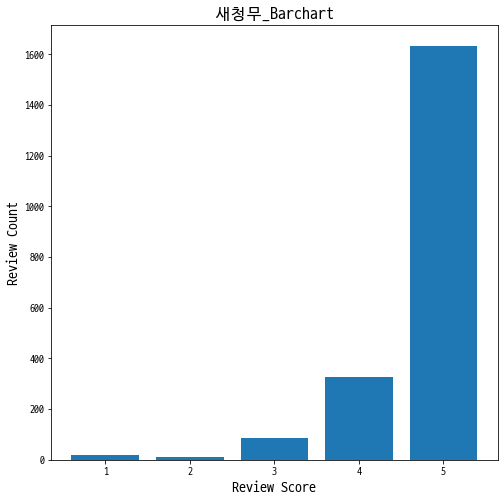

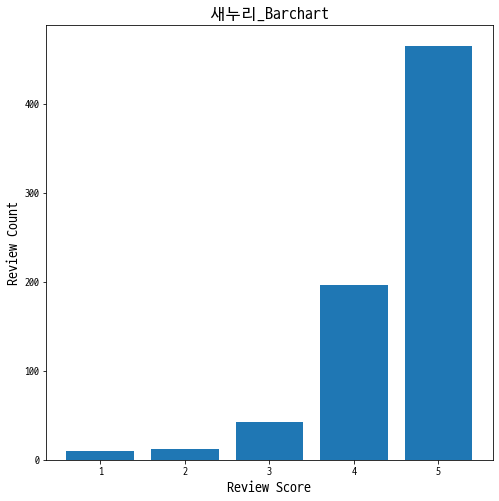

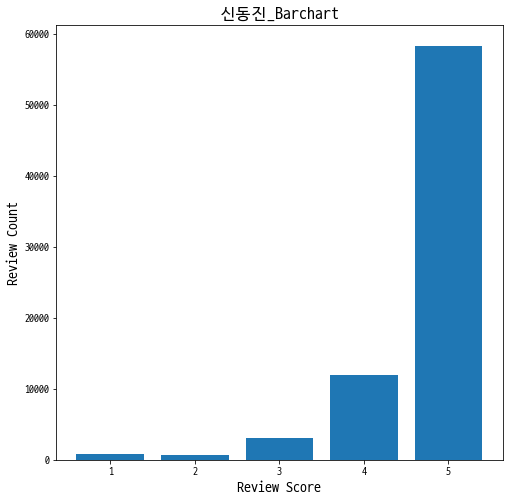

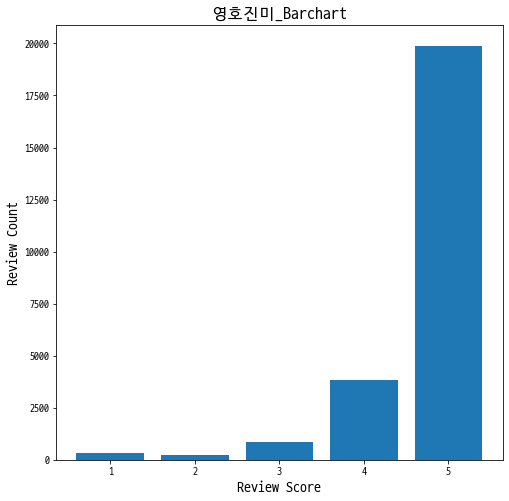

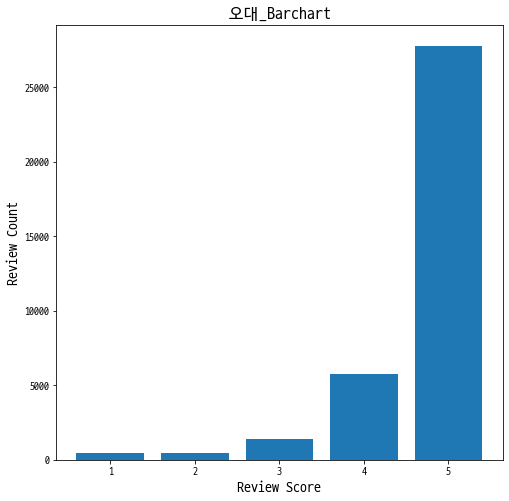

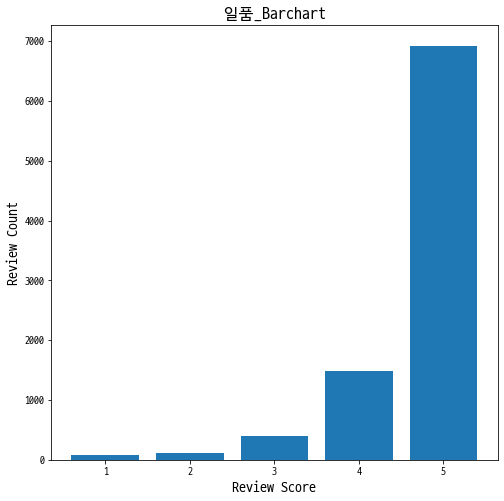

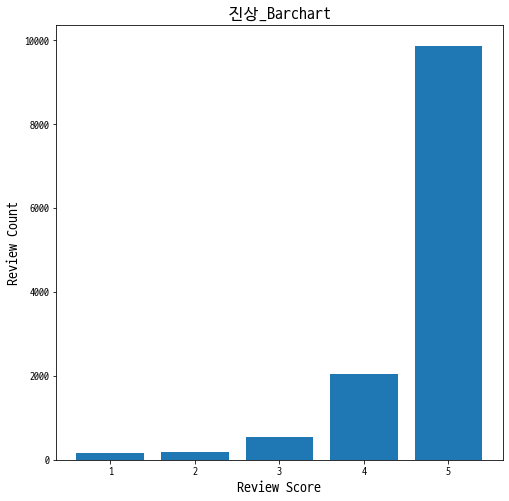

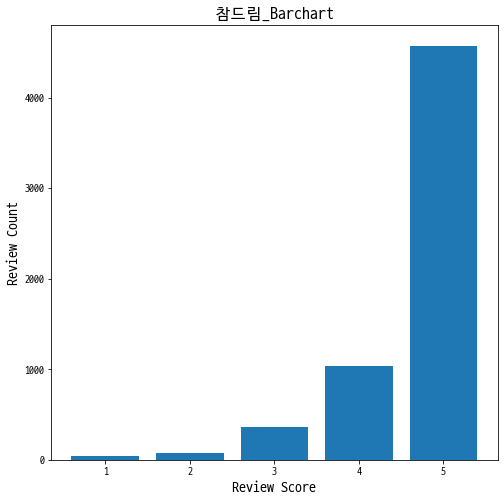

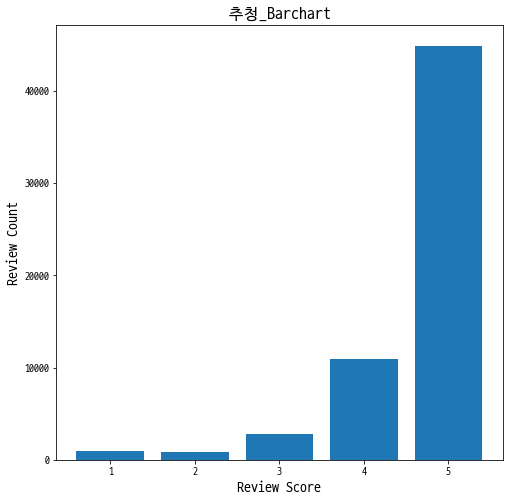

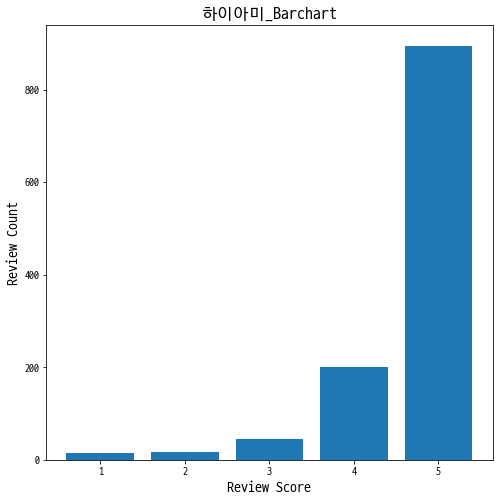

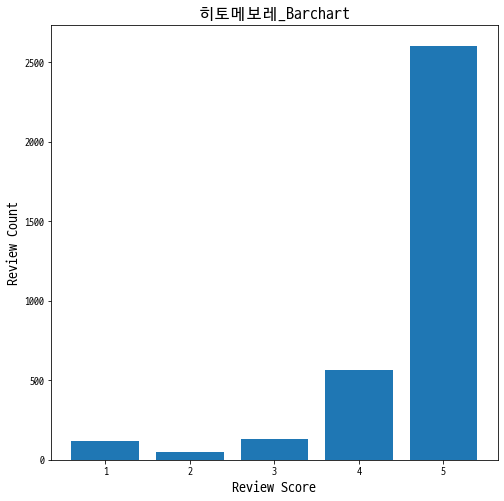

In [2]:
#01. 품종 별 평점 분포 확인하기. 
#(1) 품종 별 데이터셋 불러오기. 
for CULTIVAR in CULTIVAR_LIST :
    review_data_01= pd.read_excel(f'../data/Coupang/{CULTIVAR}.xlsx')
    review_data_01.rename(columns={'review' : 'review_01', 'rate' : 'score'}, inplace=True)
    try                       :
        review_data_02 = pd.read_excel('../data/lotteon/crawling_LotteON.xlsx', sheet_name = CULTIVAR)
    except Exception          :
        review_data_02 = pd.DataFrame({'review_01' : [np.nan]})
    globals()[f'{CULTIVAR}_data'] = pd.concat([review_data_01, review_data_02], axis=0)
    globals()[f'{CULTIVAR}_data'] = globals()[f'{CULTIVAR}_data'][['score']]
    globals()[f'{CULTIVAR}_data']['value'] = globals()[f'{CULTIVAR}_data'][['score']].astype(str)
    globals()[f'{CULTIVAR}_data'] = globals()[f'{CULTIVAR}_data'].dropna(axis=0)

#(2) 시각화하기. 
for CULTIVAR in CULTIVAR_LIST :
    plt.figure(figsize=(8,8))
    plt.bar([1,2,3,4,5], globals()[f'{CULTIVAR}_data'].groupby('value').sum().values.flatten())
    plt.title(f'{CULTIVAR}_Barchart', fontsize=16)
    plt.xlabel('Review Score', fontsize=14)
    plt.ylabel('Review Count', fontsize=14)
    plt.show()